# 06 · Datos externos: oferta, precios e IPC (parquets adicionales)
**High Garden Coffee**

**Objetivo:** enriquecer el análisis con oferta (producción, exportaciones, existencias) y precios (al productor e internacionales), **sin tocar** `coffee_db.parquet` ni duplicar filas.

## Diseño
| Decisión | Razón |
|---|---|
| **Parquet adicional** (`coffee_extra.parquet`), no columnas nuevas en el principal | Evita duplicar: el CSV `coffeedata.csv` trae **una fila por grupo de café** de la ICO; aquí se colapsa a **una fila por país-año** |
| **Inner join** con los países de `coffee_db.parquet` | El análisis se limita a los países modelados; lo demás se descarta y se reporta |
| **Precio internacional aparte** (`prices_global.parquet`) | No pertenece a un país: repetirlo en las 55 filas de cada año lo duplicaría 55 veces |
| **Precios reales** con el IPC de EE. UU. (BLS), base 2019 | Los precios de la ICO son nominales (US$/kg); sin deflactar, 1990 y 2018 no son comparables |
| **Exportaciones por año cafetero** para el balance | Con exportaciones por año calendario el balance de existencias no cierra |

**Entradas** (carpeta `datos_externos/`): `total-production.csv`, `exports-crop-year.csv`, `exports-calendar-year.csv`, `gross-opening-stocks.csv`, `indicator-prices.csv`, `coffeedata.csv`, `cpi_us_bls.csv`.
**Salidas** (`outputs/`): `coffee_extra.parquet`, `prices_global.parquet`, `prices_crop_year.parquet`.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import external_data as E
from utils import *

warnings.filterwarnings("ignore", category=DeprecationWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.options.display.float_format = "{:,.3f}".format
print("Carpeta de entradas:", E.RAW)

Carpeta de entradas: C:\Users\danil\OneDrive\Documentos\GitHub\Prueba_NTT\datos_externos


## 1. Fuentes y condiciones de uso
- **ICO (archivos históricos del comercio mundial del café):** se pueden descargar y usar citando a la ICO como fuente. La base completa (WCSD) es de pago y **no se usa**.
- **IPC-U de EE. UU. (BLS):** serie mensual, todos los ítems, sin ajuste estacional, base 1982-84 = 100. Dato oficial de un organismo público; se pide citar la fuente. Transcrita de la tabla histórica del BLS y validada (ver abajo).
- **`coffeedata.csv`:** archivo aportado; coincide con la fuente ICO (su consumo doméstico es idéntico al de `coffee_db.parquet`).

## 2. IPC de EE. UU.
La transcripción se valida contra los **promedios anuales que publica el propio BLS** en esa tabla.

In [2]:
ipc = E.leer_ipc()
anual = E.ipc_anual(ipc)
publicados = {1990: 130.7, 1996: 156.9, 2000: 172.2, 2008: 215.303, 2010: 218.056, 2016: 240.007, 2019: 255.657}
chk = pd.DataFrame({"calculado": anual.loc[list(publicados)], "publicado BLS": pd.Series(publicados)})
chk["diferencia"] = chk["calculado"] - chk["publicado BLS"]
print(f"{len(ipc)} meses ({ipc.fecha.min():%Y-%m} → {ipc.fecha.max():%Y-%m}) · nulos: {int(ipc.cpi_u_nsa.isna().sum())}")
print(f"Inflación acumulada 1990 → 2019: ×{anual[2019] / anual[1990]:.2f}  (IPC base {E.BASE_YEAR} = {anual[E.BASE_YEAR]:.3f})")
chk

360 meses (1990-01 → 2019-12) · nulos: 0
Inflación acumulada 1990 → 2019: ×1.96  (IPC base 2019 = 255.657)


,calculado,publicado BLS,diferencia
1990,130.658,130.700,-0.042
1996,156.850,156.900,-0.050
2000,172.200,172.200,0.000
2008,215.303,215.303,-0.000
2010,218.056,218.056,-0.000
2016,240.007,240.007,0.000
2019,255.657,255.657,0.000


## 3. Precios internacionales: nominal frente a real
Precios indicadores de la ICO en **US$/kg nominales** (comprobación: el mínimo de septiembre de 2001 es 0.909 US$/kg, es decir 41.2 centavos/lb × 2.2046). Se deflactan mes a mes con el IPC y se expresan en **dólares de 2019**.

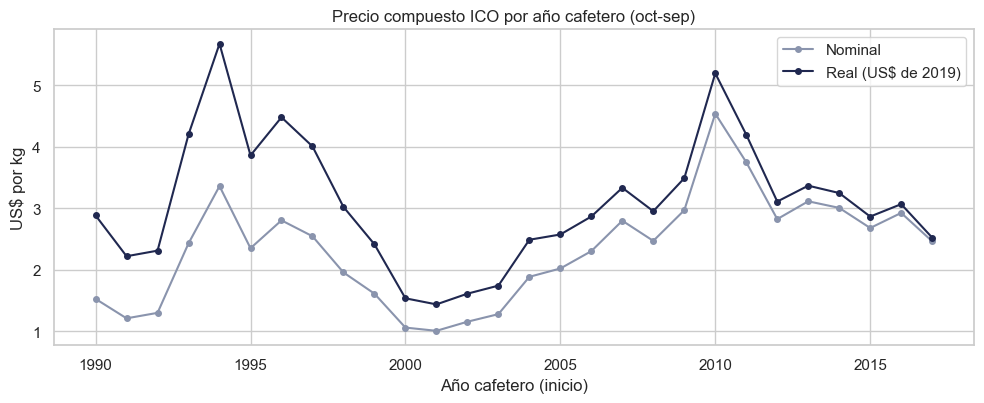

Nominal: 1.52 → 2.46 (+62%)  ·  Real: 2.88 → 2.52 (-13%)


,crop_year,ico_composite,colombian_milds,other_milds,brazilian_naturals,robustas,ico_composite_real,colombian_milds_real,other_milds_real,brazilian_naturals_real,robustas_real,n_meses,completo
26,2015,2.678,3.271,3.478,2.906,1.835,2.864,3.499,3.720,3.108,1.963,12,True
27,2016,2.923,3.505,3.522,3.055,2.287,3.066,3.676,3.695,3.204,2.398,12,True
28,2017,2.462,3.058,2.962,2.581,1.929,2.521,3.132,3.033,2.643,1.975,12,True
29,2018,2.365,3.002,2.955,2.435,1.813,2.399,3.045,2.997,2.470,1.839,3,False


In [3]:
precios, ipc_base = E.construir_precios()
por_anio = E.precios_por_anio_cafetero(precios)
completos = por_anio[por_anio.completo].set_index("crop_year")

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(completos.index, completos["ico_composite"], marker="o", ms=4, color="#8a94ad", label="Nominal")
ax.plot(completos.index, completos["ico_composite_real"], marker="o", ms=4, color="#202850", label="Real (US$ de 2019)")
ax.set(title="Precio compuesto ICO por año cafetero (oct-sep)", xlabel="Año cafetero (inicio)", ylabel="US$ por kg")
ax.legend()
plt.tight_layout(); save_fig("ext_precio_nominal_vs_real"); plt.show()

comp = completos.loc[[1990, 2017], ["ico_composite", "ico_composite_real"]]
comp["cambio"] = ""
print(f"Nominal: {comp.iloc[0,0]:.2f} → {comp.iloc[1,0]:.2f} ({comp.iloc[1,0]/comp.iloc[0,0]-1:+.0%})  ·  "
      f"Real: {comp.iloc[0,1]:.2f} → {comp.iloc[1,1]:.2f} ({comp.iloc[1,1]/comp.iloc[0,1]-1:+.0%})")
por_anio.tail(4)

**Lectura.** En términos nominales el precio subió; en términos reales **bajó**. Sin deflactar se concluiría lo contrario. Los años cafeteros 1989 (solo ene-sep 1990) y 2018 (solo oct-dic 2018) están incompletos y se marcan con `completo = False`.

## 4. Parquet adicional a nivel país-año
### 4.1 El problema de la duplicación por tipo de café

In [4]:
raw = pd.read_csv(E.RAW / "coffeedata.csv")
filas = raw.groupby(["Country", "Year"]).size()
print(f"coffeedata.csv: {len(raw):,} filas para {len(filas):,} país-año  →  {int((filas == 2).sum())} país-año vienen DUPLICADOS (uno por grupo de café)")
print("Grupos de café:", raw.Coffee_type.value_counts().to_dict())
ej = raw[(raw.Country == "Brazil") & (raw.Year == 1990)][["Country", "Year", "Coffee_type", "Production", "Exports", "Domestic_consumption", "Price_grower"]]
ej

coffeedata.csv: 1,920 filas para 1,440 país-año  →  480 país-año vienen DUPLICADOS (uno por grupo de café)
Grupos de café: {'Robustas': 810, 'Other Milds': 810, 'Brazilan Naturals': 210, 'Colombian Milds': 90}


,Country,Year,Coffee_type,Production,Exports,Domestic_consumption,Price_grower
3,Brazil,1990,Brazilan Naturals,"27,285.629","16,935.788","8,200.000",54.325
4,Brazil,1990,Robustas,"27,285.629","16,935.788","8,200.000",34.849


La producción, las exportaciones y el consumo son **idénticos** en las dos filas (sumarlas duplicaría el dato); solo el precio al productor cambia por grupo. Por eso se **colapsa a país-año**: lo repetido se toma una vez y el precio se **promedia** entre grupos (con el número de grupos en `n_price_groups`).

In [5]:
extra, rep = E.construir_extra()
print({k: v for k, v in rep.items() if k != "ipc_base"})
print(f"\nFilas: {len(extra):,}  ·  duplicados país-año: {int(extra.duplicated(['country', 'year']).sum())}")
extra.head(3)

{'paises_parquet': 55, 'paises_extra': 55, 'paises_parquet_sin_datos_extra': [], 'descartados_por_inner_join': ['Benin'], 'filas': 1643, 'anio_base_real': 2019}

Filas: 1,643  ·  duplicados país-año: 0


,country,year,season,production_kg,exports_crop_kg,exports_cal_kg,opening_stocks_kg,domestic_consumption_kg,consumption_share_prod,export_crop_share_prod,implied_closing_stocks_kg,balance_gap_pct,price_grower_arabica_usd_kg,price_grower_arabica_real_usd_kg,price_grower_robusta_usd_kg,price_grower_robusta_real_usd_kg,price_grower_usd_kg,price_grower_real_usd_kg,n_price_groups,source_supply
0,Angola,1990,1990/91,"3,020,700.000","4,760,700.000","5,061,000.000","12,600,000.000",1200000,0.397,1.576,"9,660,000.000",0.000,NaN,NaN,1.888,3.695,1.888,3.695,1.000,ico_csv
1,Angola,1991,1991/92,"4,759,860.000","4,459,860.000","4,230,060.000","9,660,000.000",1800000,0.378,0.937,"8,160,000.000",0.000,NaN,NaN,2.009,3.771,2.009,3.771,1.000,ico_csv
2,Angola,1992,1992/93,"4,651,200.000","4,051,200.000","4,815,000.000","8,160,000.000",2100000,0.451,0.871,"6,660,000.000",0.000,NaN,NaN,0.990,1.804,0.990,1.804,1.000,ico_csv


### 4.2 Inner join con `coffee_db.parquet`

In [6]:
paises, _ = E.leer_parquet_principal()
print(f"Países en el parquet principal: {len(paises)}  ·  en el parquet adicional: {extra.country.nunique()}")
print("Descartados por el inner join (están en los CSV pero no en el parquet):", rep["descartados_por_inner_join"])
print("Países del parquet SIN datos externos:", rep["paises_parquet_sin_datos_extra"] or "ninguno")
cobertura = extra.groupby("year").country.nunique()
print("\nPaíses por año (1990 · 2018 · 2019):", cobertura.loc[[1990, 2018, 2019]].to_dict())
print("Sin fila en 2019 (no están en coffeedata.csv):", sorted(set(paises) - set(extra[extra.year == 2019].country)))

Países en el parquet principal: 55  ·  en el parquet adicional: 55
Descartados por el inner join (están en los CSV pero no en el parquet): ['Benin']
Países del parquet SIN datos externos: ninguno

Países por año (1990 · 2018 · 2019): {1990: 55, 2018: 55, 2019: 48}
Sin fila en 2019 (no están en coffeedata.csv): ['Equatorial Guinea', 'Guyana', "Lao People's Democratic Republic", 'Nepal', 'Paraguay', 'Timor-Leste', 'Yemen']


In [7]:
nulos = (extra.isna().mean() * 100).round(1).rename("% nulos").to_frame()
nulos["motivo"] = ""
nulos.loc["exports_crop_kg", "motivo"] = "2019: no hay exportaciones por año cafetero"
nulos.loc["price_grower_usd_kg", "motivo"] = "el precio al productor solo existe para parte de país-años"
nulos.loc["n_price_groups", "motivo"] = "7 países no están en coffeedata.csv"
nulos[nulos["% nulos"] > 0]

,% nulos,motivo
exports_crop_kg,2.900,2019: no hay exportaciones por año cafetero
consumption_share_prod,4.000,
export_crop_share_prod,6.900,
implied_closing_stocks_kg,2.900,
balance_gap_pct,7.400,
price_grower_arabica_usd_kg,57.800,
price_grower_arabica_real_usd_kg,57.800,
price_grower_robusta_usd_kg,70.800,
price_grower_robusta_real_usd_kg,70.800,
price_grower_usd_kg,43.800,el precio al productor solo existe para parte ...


### 4.3 Precio al productor: por tipo de café
El precio al productor de la ICO viene por **grupo de café** (Colombian Milds, Other Milds y Brazilian Naturals son Arábica; Robustas es Robusta). Promediar los grupos de un país es engañoso cuando cambia **cuántos grupos reportan**: el promedio salta sin que el precio de ningún mercado se haya movido. Por eso el parquet trae el precio **por tipo** (`price_grower_arabica_*`, `price_grower_robusta_*`), y el promedio (`price_grower_usd_kg`) queda solo por compatibilidad.

In [8]:
t = extra[extra.country == "Thailand"].set_index("year")
cols = ["price_grower_arabica_real_usd_kg", "price_grower_robusta_real_usd_kg", "price_grower_real_usd_kg", "n_price_groups"]
display(t.loc[[2008, 2012, 2013, 2014], cols].rename(columns={cols[0]: "Arábica", cols[1]: "Robusta", cols[2]: "promedio de grupos", cols[3]: "grupos"}))
a, b = t.loc[2008], t.loc[2013]
print(f"Tailandia 2008 → 2013 (real):  promedio de grupos {b[cols[2]] / a[cols[2]] - 1:+.1%}   |   Robusta contra Robusta {b[cols[1]] / a[cols[1]] - 1:+.1%}")
g = extra[extra.n_price_groups > 0].sort_values(["country", "year"])
cambia = g.groupby("country").n_price_groups.diff().fillna(0) != 0
print(f"Países-año donde cambia el número de grupos que reportan: {int(cambia.sum())} de {len(g):,}")

,Arábica,Robusta,promedio de grupos,grupos
year,,,,
2008,NaN,2.192,2.192,1.000
2012,NaN,2.531,2.531,1.000
2013,4.922,2.511,3.716,2.000
2014,2.698,2.191,2.445,2.000


Tailandia 2008 → 2013 (real):  promedio de grupos +69.5%   |   Robusta contra Robusta +14.5%
Países-año donde cambia el número de grupos que reportan: 21 de 924


## 5. Validaciones

In [9]:
# 5.1 balance de existencias: producción + existencias iniciales − exportaciones (año cafetero) − consumo = existencias del año siguiente
g = extra[extra.production_kg / 60 / 1000 > 500].balance_gap_pct.abs().dropna()
print(f"Balance de existencias (países con >500 mil sacos, n={len(g)}): error mediano {g.median():.2%} · p90 {g.quantile(.9):.1%}")

# 5.2 el cambio de fuente en 2019 (ICO → coffeedata) no introduce saltos
p = extra.pivot(index="country", columns="year", values="production_kg")
r = (p[2019] / p[2018]).replace([np.inf, -np.inf], np.nan).dropna()[p[2018] > 30e6]   # > 0.5 M de sacos
print(f"Producción 2019/2018 (n={len(r)}): mediana {r.median():.2f} · p10 {r.quantile(.1):.2f} · p90 {r.quantile(.9):.2f}")

# 5.3 el consumo del parquet adicional es EXACTAMENTE el del principal
_, cons = E.leer_parquet_principal()
m = extra.merge(cons, on=["country", "year"], suffixes=("", "_principal"))
print("Consumo doméstico idéntico al parquet principal:", bool((m.domestic_consumption_kg == m.domestic_consumption_kg_principal).all()), f"({len(m):,} filas)")

Balance de existencias (países con >500 mil sacos, n=690): error mediano 0.00% · p90 14.8%
Producción 2019/2018 (n=20): mediana 0.93 · p10 0.81 · p90 1.18
Consumo doméstico idéntico al parquet principal: True (1,643 filas)


In [10]:
import test_external_data as T

pruebas = T.run_all(verbose=False)
print(pruebas.resultado.value_counts().to_string())
pruebas

resultado
OK    16


,prueba,resultado,detalle
0,test_build_is_reproducible,OK,
1,test_cents_per_lb_conversion,OK,
2,test_coffee_type_duplication_is_collapsed,OK,
3,test_consumption_column_equals_main_parquet,OK,
4,test_cpi_is_complete_and_positive,OK,
5,test_cpi_matches_published_bls_annual_averages,OK,
6,test_crop_year_assignment_and_completeness,OK,
7,test_extra_is_unique_per_country_year_and_inne...,OK,
8,test_grower_price_real_uses_annual_cpi,OK,
9,test_no_negative_values_and_coverage,OK,


## 6. Una primera lectura útil: ¿cuánto de lo producido se exporta?
Participación del consumo doméstico y de las exportaciones (año cafetero) en la producción de 2018/19, para los mercados del ranking. Es el dato que faltaba para interpretar el ranking: un mercado con mucho consumo doméstico pero casi todo su café exportado no compite con el exportador por el grano.

In [11]:
ranking_path = OUT / "ranking.parquet"
if ranking_path.exists():
    rk = pd.read_parquet(ranking_path).sort_values("posicion").head(12)
    alias = {"Vietnam": "Viet Nam", "Bolivia": "Bolivia (Plurinational State of)"}
    e18 = extra[extra.year == 2018].set_index("country")
    filas = []
    for _, r in rk.iterrows():
        c = alias.get(r.country, r.country)
        if c in e18.index:
            x = e18.loc[c]
            filas.append({"posición": int(r.posicion), "país": r.country, "producción (M sacos)": x.production_kg / 60 / 1e6,
                          "consumo/producción": x.consumption_share_prod, "exportación/producción": x.export_crop_share_prod})
    display(pd.DataFrame(filas).set_index("posición"))
else:
    print("Ejecuta antes el notebook 04 para generar outputs/ranking.parquet.")

,país,producción (M sacos),consumo/producción,exportación/producción
posición,,,,
1,Brazil,62.925,0.353,0.598
2,Ethiopia,7.776,0.474,0.489
3,Vietnam,31.174,0.083,0.849
4,Indonesia,9.418,0.510,0.501
5,Philippines,0.206,16.003,0.030
6,Colombia,13.858,0.129,0.974
7,Thailand,0.482,2.905,0.373
8,Mexico,4.351,0.563,0.615
9,Bolivia,0.083,0.727,0.273


Notas:
- Exportación/producción puede superar 100% cuando el país vende existencias de años anteriores, y consumo + exportación no suman 100% porque hay variación de existencias.
- **Filipinas (16×) y Tailandia (2.9×) consumen más de lo que producen.** Esa diferencia solo puede cubrirse con importaciones o existencias (las existencias son mínimas). Los archivos de importaciones de la ICO **no incluyen esos países**, así que aquí no se puede confirmar cuánto importan: es una hipótesis a validar con otra fuente (por ejemplo USDA PSD).

## 7. Guardar

In [12]:
E.guardar(extra, precios, por_anio)
for f in ("coffee_extra", "prices_global", "prices_crop_year"):
    d = pd.read_parquet(OUT / f"{f}.parquet")
    print(f"{f}.parquet  →  {d.shape[0]:,} filas × {d.shape[1]} columnas")

coffee_extra.parquet  →  1,643 filas × 20 columnas
prices_global.parquet  →  348 filas × 13 columnas
prices_crop_year.parquet  →  30 filas × 13 columnas


## 8. Conclusiones y límites
1. **Sin duplicación:** 480 país-año venían duplicados por grupo de café; el parquet adicional queda con **una fila por país-año** (sin duplicados) y solo con los 55 países de `coffee_db.parquet` (Benin se descarta).
2. **El balance cierra:** con exportaciones por año cafetero, producción + existencias − exportaciones − consumo reproduce las existencias del año siguiente (error mediano 0.00%; p90 14.8%).
3. **Precios reales:** el precio internacional compuesto subió en términos nominales (1.52 → 2.46 US$/kg entre 1990/91 y 2017/18) pero **bajó en reales de 2019** (2.88 → 2.52).
4. **Cobertura:** 2019 solo tiene 48 países (`coffeedata.csv` no trae 7) y sin exportaciones por año cafetero; el precio al productor existe para alrededor del 56% de los país-años. Los precios internacionales llegan hasta diciembre de 2018.
   **La cobertura del precio al productor cae con los años:** de los 51 países modelados lo reportaban 42 en 1990, 25 en 2013 y 15 en 2018 (44 de 51 lo reportan en algún año). Por eso comparar solo 2013→2018 deja 14 países y 2008→2013, 22. La propia tabla oficial de la ICO muestra la misma caída (24 países en 2013, 16 en 2017): no es una pérdida del cruce con el parquet principal.
5. **Precio al productor por tipo de café:** el promedio de los grupos de un país salta cuando cambia cuántos grupos reportan (Tailandia 2008 → 2013: +69.5% en el promedio, +14.5% comparando Robusta con Robusta). Para describir o comparar precios usa `price_grower_arabica_*` y `price_grower_robusta_*`; Arábica y Robusta no son comparables entre sí.
6. **Precio al productor real:** se deflacta con el IPC anual del año calendario. Que `Year` sea año calendario y el precio esté en centavos por libra lo confirma la tabla oficial de la ICO *Prices paid to growers* ("Calendar years", "In US cents/lb"). Contrastada con `coffeedata.csv` (verificación manual, no forma parte del ETL): 1,106 valores comparables, 97.5% idénticos; los otros 28 son revisiones menores (sobre todo Uganda, hasta 14 c/lb). La tabla de la ICO termina en 2017; `coffeedata.csv` aporta 2018-2019.
7. **Lectura para el ranking:** Vietnam exporta ~85% de lo que produce y consume solo ~8%, mientras Filipinas y Tailandia consumen más de lo que producen. Es una pista sobre quién compite por el grano y quién podría ser comprador, pendiente de confirmar con datos de importación.
8. **IPC de EE. UU. como deflactor:** es el estándar para materias primas cotizadas en dólares, pero no mide la inflación local del productor.

**Siguiente:** usar `prices_crop_year.parquet` (unir por `crop_year = year`) para el pronóstico de rangos de precio, y el consumo de los mercados importadores (Excel `coffee_trade.xlsx`) como parquet aparte, porque esos países no están en `coffee_db.parquet`.